# Cell 1 — Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

df = pd.read_csv("02_data_cleaning/cleaned_data/jobs_clean.csv")
print(f"Dataset: {len(df)} jobs across {df['job_category'].nunique()} categories")
print(df['job_category'].value_counts())

Dataset: 562 jobs across 7 categories
job_category
Data Analyst        179
Business Analyst    111
AI/ML Analyst       100
BI Analyst           69
Data Engineer        66
Other Analyst        23
Other                14
Name: count, dtype: int64


# Cell 2 — Which job category has the most openings?

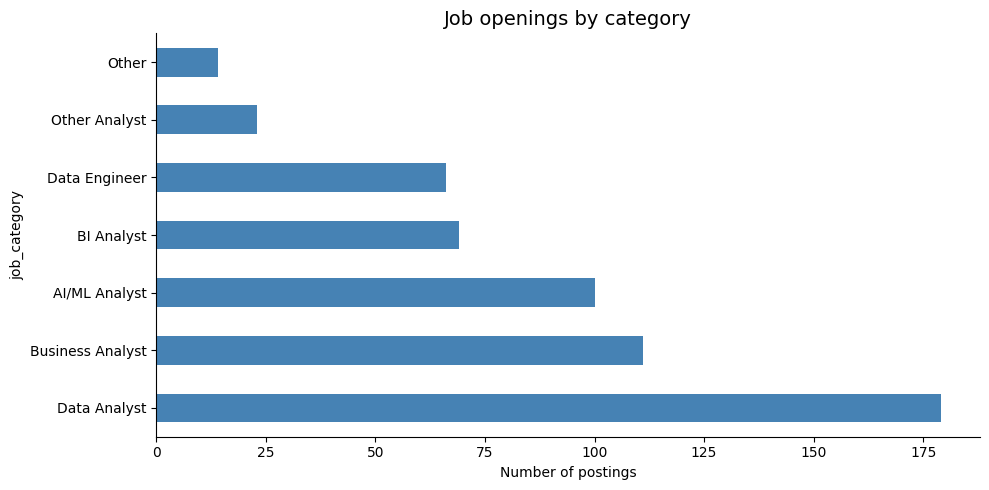

In [4]:
ax = df['job_category'].value_counts().plot(kind='barh', color='steelblue')
ax.set_title("Job openings by category", fontsize=14)
ax.set_xlabel("Number of postings")
plt.tight_layout()
plt.savefig("03_analysis/chart_job_categories.png", dpi=150)
plt.show()

# Cell 3 — Which skills are most in demand?

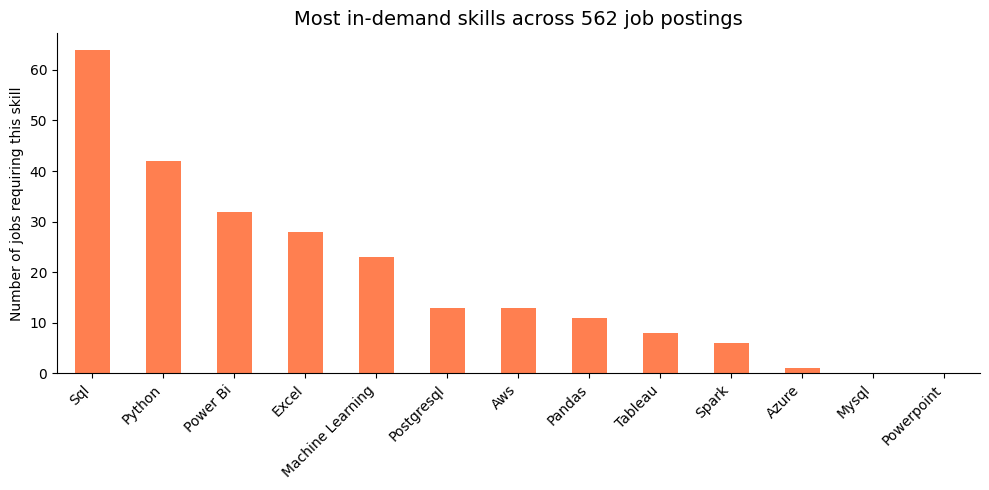

In [5]:
skill_cols = [c for c in df.columns if c.startswith('skill_')]
skill_totals = df[skill_cols].sum().sort_values(ascending=False)
skill_totals.index = [s.replace('skill_','').replace('_',' ').title()
                      for s in skill_totals.index]

ax = skill_totals.plot(kind='bar', color='coral')
ax.set_title("Most in-demand skills across 562 job postings", fontsize=14)
ax.set_ylabel("Number of jobs requiring this skill")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("03_analysis/chart_skills.png", dpi=150)
plt.show()

# Cell 4 — Which cities hire the most?

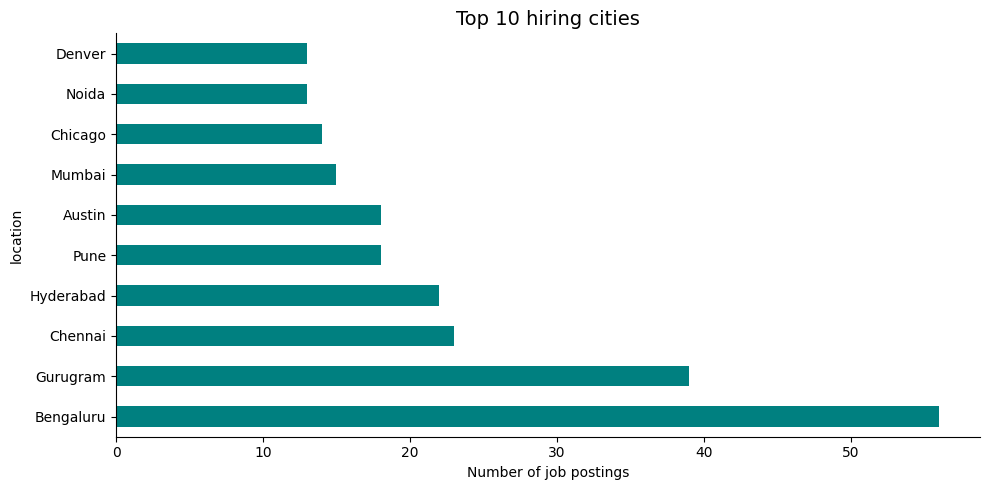

In [6]:
city_counts = df[df['location'] != 'India (unspecified)']['location'].value_counts().head(10)
ax = city_counts.plot(kind='barh', color='teal')
ax.set_title("Top 10 hiring cities", fontsize=14)
ax.set_xlabel("Number of job postings")
plt.tight_layout()
plt.savefig("03_analysis/chart_cities.png", dpi=150)
plt.show()

# Cell 5 — Remote vs On-site

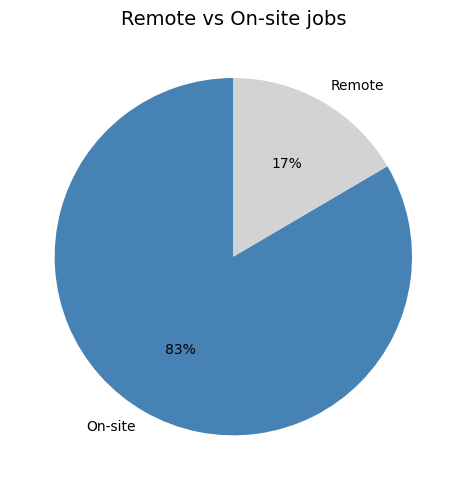

In [7]:
remote_counts = df['is_remote'].map({True: 'Remote', False: 'On-site'}).value_counts()
ax = remote_counts.plot(kind='pie', autopct='%1.0f%%',
      colors=['steelblue','lightgray'], startangle=90)
ax.set_title("Remote vs On-site jobs", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("03_analysis/chart_remote.png", dpi=150)
plt.show()

# Cell 6 — Experience required breakdown

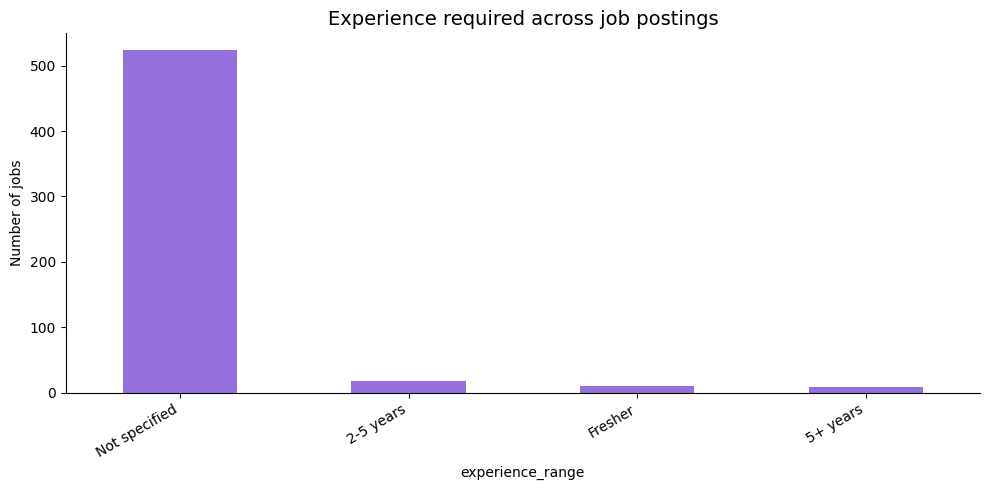

In [8]:
exp_counts = df['experience_range'].value_counts()
ax = exp_counts.plot(kind='bar', color='mediumpurple')
ax.set_title("Experience required across job postings", fontsize=14)
ax.set_ylabel("Number of jobs")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("03_analysis/chart_experience.png", dpi=150)
plt.show()

# Cell 7 — Salary disclosure rate (key insight!)

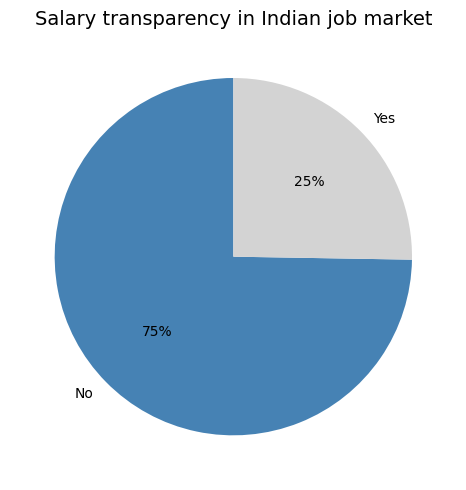

Key insight: Only 142 out of 562 jobs disclose salary — that's 25.3 %


In [9]:
sal_counts = df['salary_disclosed'].value_counts()
ax = sal_counts.plot(kind='pie', autopct='%1.0f%%',
      colors=['steelblue','lightgray'], startangle=90)
ax.set_title("Salary transparency in Indian job market", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("03_analysis/chart_salary.png", dpi=150)
plt.show()
print("Key insight: Only", sal_counts.get('Yes',0),
      "out of", len(df), "jobs disclose salary — that's",
      round(sal_counts.get('Yes',0)/len(df)*100,1), "%")

# Cell 8 — Job postings trend over time

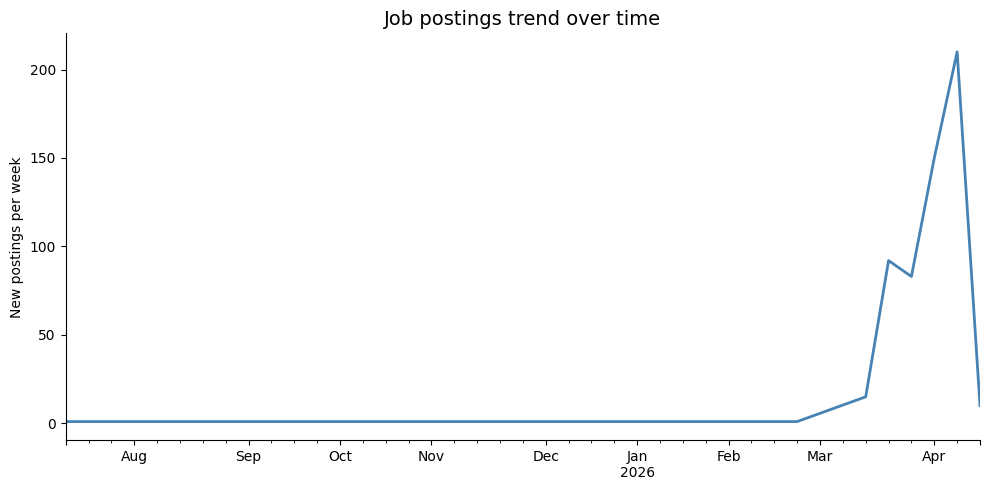

In [10]:
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
trend = df.groupby(df['date_posted'].dt.to_period('W')).size()
ax = trend.plot(kind='line', color='steelblue', linewidth=2)
ax.set_title("Job postings trend over time", fontsize=14)
ax.set_ylabel("New postings per week")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("03_analysis/chart_trend.png", dpi=150)
plt.show()